# Week 5 – Regression Practical

The goal is to predict the next week's quiz score using information available from the current and previous weeks.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("synthetic-regression-dataset.csv")

df.head()

,student_key,course_week,group_code,current_quiz_score_pct,previous_task_score_pct,concept_map_score_pct,monday_activity_count,task_attempts,attendance_recorded,task_submitted,submission_delay_minutes,submission_timing,project_activity_count,prior_average_quiz_pct,cumulative_attendance_rate,next_week_quiz_grade_0_5,next_week_quiz_score_pct
0,SYN001,1,G06,43.2,53.9,56.3,19,1,1,0,NaN,not_submitted,2.0,43.2,1.000,1,38.6
1,SYN001,2,G06,38.6,35.5,52.6,14,0,0,1,-84.2,early,2.0,40.9,0.500,2,43.4
2,SYN001,3,G06,43.4,49.2,53.9,22,1,1,1,85.3,late,0.0,41.7,0.667,2,47.9
3,SYN001,4,G06,47.9,37.1,67.9,24,2,1,0,NaN,not_submitted,3.0,43.3,0.750,2,57.6
4,SYN001,5,G06,57.6,50.1,65.8,22,2,1,0,NaN,not_submitted,NaN,46.1,0.800,2,47.6


In [4]:
print("Rows and columns:", df.shape)
df.info()

Rows and columns: (280, 17)
<class 'pandas.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_key                 280 non-null    str    
 1   course_week                 280 non-null    int64  
 2   group_code                  280 non-null    str    
 3   current_quiz_score_pct      266 non-null    float64
 4   previous_task_score_pct     258 non-null    float64
 5   concept_map_score_pct       260 non-null    float64
 6   monday_activity_count       280 non-null    int64  
 7   task_attempts               280 non-null    int64  
 8   attendance_recorded         280 non-null    int64  
 9   task_submitted              280 non-null    int64  
 10  submission_delay_minutes    219 non-null    float64
 11  submission_timing           280 non-null    str    
 12  project_activity_count      272 non-null    float64
 13  prior_average_quiz

## Part A – Prediction problem

**Observation:** One row represents one student in one course week.

**Target:** 'next_week_quiz_score_pct'

**Prediction point:** The prediction is made using information from the current and previous weeks to predict the next week's quiz score.

**Available information:** current quiz score, previous task score, concept map score, activity, attempts, attendance and previous quiz performance.

**Possible future information:** 'next_week_quiz_grade_0_5' should not be used because it describes the same future quiz we are trying to predict.

**Identifiers:** 'student_key' and 'group_code' are identifiers/group information and are not useful as direct numerical predictors here.

**Missing values:** Some columns contain missing values.

**Large error:** A large error means the predicted next quiz percentage is far from the student's actual next quiz percentage.

In [5]:
df.isna().sum()

student_key                    0
course_week                    0
group_code                     0
current_quiz_score_pct        14
previous_task_score_pct       22
concept_map_score_pct         20
monday_activity_count          0
task_attempts                  0
attendance_recorded            0
task_submitted                 0
submission_delay_minutes      61
submission_timing              0
project_activity_count         8
prior_average_quiz_pct         0
cumulative_attendance_rate     0
next_week_quiz_grade_0_5       0
next_week_quiz_score_pct       0
dtype: int64

## Part B – Features and target

I selected information that is available before the next week's quiz score is known. The target is the next week's quiz score.

In [6]:
features = [
    "current_quiz_score_pct",
    "previous_task_score_pct",
    "concept_map_score_pct",
    "monday_activity_count",
    "task_attempts",
    "attendance_recorded",
    "prior_average_quiz_pct",
    "cumulative_attendance_rate"
]

target = "next_week_quiz_score_pct"

X = df[features]
y = df[target]

In [7]:
X = X.fillna(X.median())

print("Number of features:", X.shape[1])
print("Missing values left:", X.isna().sum().sum())

Number of features: 8
Missing values left: 0


## Part C – Train/test split

I split the data into training and test sets. I used 25% of the data for testing and a fixed random state so the result can be reproduced.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 210
Test rows: 70


## Part D – Baseline

I used DummyRegressor as a baseline. It predicts the mean quiz score from the training data. This gives a simple result to compare the real models with.

In [9]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

dummy_mae = mean_absolute_error(y_test, dummy_pred)

print("Baseline MAE:", round(dummy_mae, 2))

Baseline MAE: 11.62


## Part E – Linear Regression

Next I trained a Linear Regression model and used it to predict the test data.

In [10]:
linear = LinearRegression()
linear.fit(X_train, y_train)

linear_pred = linear.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)

print("Linear Regression MAE:", round(linear_mae, 2))

Linear Regression MAE: 6.81


In [11]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": linear_pred
})

results["Residual"] = results["Actual"] - results["Predicted"]

results.head()

,Actual,Predicted,Residual
33,91.7,80.923718,10.776282
108,58.4,56.243954,2.156046
240,63.5,68.045967,-4.545967
259,75.5,66.298290,9.201710
154,53.2,60.533715,-7.333715


## Part F – Ridge Regression

I also tested Ridge regression to compare it with Linear Regression.

In [12]:
ridge = Ridge()
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_pred)

print("Ridge MAE:", round(ridge_mae, 2))

Ridge MAE: 6.81


## Model evaluation

I compared the three models using MAE, RMSE and R².

In [13]:
models = {
    "DummyRegressor": dummy_pred,
    "LinearRegression": linear_pred,
    "Ridge": ridge_pred
}

for name, pred in models.items():
    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred)

    print(name)
    print("MAE:", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R²:", round(r2, 2))
    print()

DummyRegressor
MAE: 11.62
RMSE: 13.72
R²: -0.1

LinearRegression
MAE: 6.81
RMSE: 8.29
R²: 0.6

Ridge
MAE: 6.81
RMSE: 8.29
R²: 0.6



### Observation

Linear Regression and Ridge performed much better than the baseline. Their MAE was 6.81, so the predictions were off by about 6.8 percentage points on average. Both models gave almost the same result.

## Actual vs predicted

I plotted the actual quiz scores against the predictions from Linear Regression.

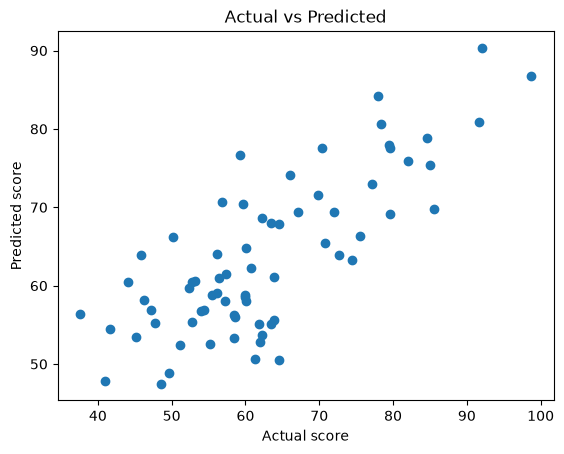

In [14]:
plt.scatter(y_test, linear_pred)

plt.xlabel("Actual score")
plt.ylabel("Predicted score")
plt.title("Actual vs Predicted")

plt.show()

## Residuals

Residuals show the difference between the actual and predicted scores.

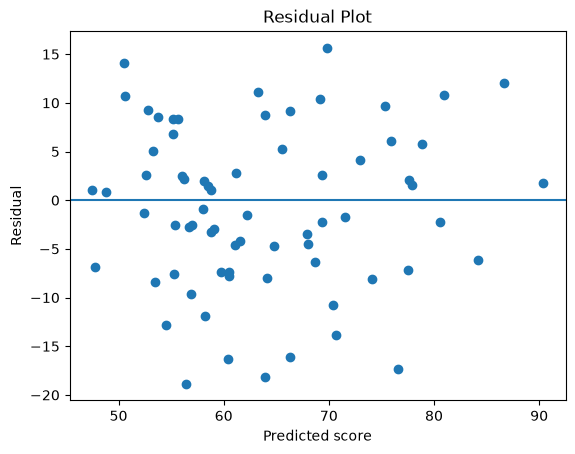

In [15]:
residuals = y_test - linear_pred

plt.scatter(linear_pred, residuals)
plt.axhline(0)

plt.xlabel("Predicted score")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

## Validation with different splits

I repeated Linear Regression with different random train/test splits to check if the result stays similar.

In [16]:
for state in [10, 20, 30, 42]:
    X_train2, X_test2, y_train2, y_test2 = train_test_split(
        X, y, test_size=0.25, random_state=state
    )

    model = LinearRegression()
    model.fit(X_train2, y_train2)
    pred = model.predict(X_test2)

    mae = mean_absolute_error(y_test2, pred)
    rmse = mean_squared_error(y_test2, pred) ** 0.5
    r2 = r2_score(y_test2, pred)

    print(state, "- MAE:", round(mae, 2),
          "RMSE:", round(rmse, 2),
          "R²:", round(r2, 2))

10 - MAE: 7.32 RMSE: 8.89 R²: 0.69
20 - MAE: 7.17 RMSE: 8.76 R²: 0.67
30 - MAE: 7.56 RMSE: 9.12 R²: 0.66
42 - MAE: 6.81 RMSE: 8.29 R²: 0.6


### Observation

The results changed a little with different train/test splits, but the overall performance stayed similar. MAE was around 7 and R² stayed between 0.60 and 0.69, so the result seems reasonably stable.

## Conclusion and limitations

Linear Regression and Ridge both performed better than the DummyRegressor baseline. Their MAE was 6.81 compared with 11.62 for the baseline. Ridge did not improve the result compared with Linear Regression.

The model is useful for estimating the next week's quiz score, but the predictions are not exact. Some residuals are quite large. Also, the dataset has repeated students, so a random row split may put data from the same student in both training and test sets. A student-based or time-based split could be tested in future.